# Task 4 — ERCOT Demand Response: Plots (LP energy-budget formulation)
Reads from CSV outputs produced by `task4_dr_budget_lp.jl`. Re-run that script to refresh data.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

# ── Parameters (must match task4.jl) ──────────────────────────────────────────
PSELL             = 55.0    # $/MWh  bilateral contract price
P_WIND            = 16.0    # $/MWh  wind tolling price
P_SOLAR           = 13.0    # $/MWh  solar tolling price
P_DR              = 100.0   # $/MW   DR retainer
QDR_MAX           = 2.0     # MW     DR contracted capacity cap
EC_WIND           = 10.0    # MW     wind nameplate
EC_SOLAR          = 10.0    # MW     solar nameplate
LAMBDA            = 0.5
ALPHA             = 0.05

BASE = os.path.dirname(os.path.abspath('task4_plots.ipynb'))
DATA_DIR    = os.path.join(BASE, 'task4', 'task4_data')
RESULTS_DIR = os.path.join(BASE, 'results', 'task4_lp')

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

## Load data

In [22]:
# Raw market data
prices_df = pd.read_csv(os.path.join(DATA_DIR, 'prices_summer.csv'), parse_dates=['datetime_utc'])
wind_df   = pd.read_csv(os.path.join(DATA_DIR, 'wind_cf_summer.csv'),  parse_dates=['datetime_utc'])
solar_df  = pd.read_csv(os.path.join(DATA_DIR, 'solar_cf_summer.csv'), parse_dates=['datetime_utc'])

# Result CSVs
contract   = pd.read_csv(os.path.join(RESULTS_DIR, 'baseline_optimal_contract.csv'))
profits    = pd.read_csv(os.path.join(RESULTS_DIR, 'baseline_scenario_profits.csv'))
dr_disp    = pd.read_csv(os.path.join(RESULTS_DIR, 'baseline_dr_dispatch.csv'))
tail_df    = pd.read_csv(os.path.join(RESULTS_DIR, 'tail_scenario_analysis.csv'))

# LP outputs use qdr{QDR_MAX} column names directly — no rename needed
qdr_max_label = f'qdr{int(QDR_MAX)}'

# Build T×N price matrix (720 hours × 40 scenarios)
prices_df['year']  = prices_df['datetime_utc'].dt.year
prices_df['month'] = prices_df['datetime_utc'].dt.month
scenario_keys = sorted(set(zip(prices_df['year'], prices_df['month'])))
T, N = 720, len(scenario_keys)
pi_mat = np.zeros((T, N))
for j, (yr, mo) in enumerate(scenario_keys):
    rows = prices_df[(prices_df['year']==yr) & (prices_df['month']==mo)].sort_values('datetime_utc')
    pi_mat[:, j] = rows['lmp_usd_mwh'].values[:T]

# Continuous dispatch matrix (T × N); derive binary active flag (dispatch > 0)
scen_cols = [c for c in dr_disp.columns if c != 't']
disp_mat  = dr_disp[scen_cols].values.astype(float)   # shape (720, 40), MWh/h
y_mat     = (disp_mat > 0).astype(int)                # 1 where any DR dispatched

print(f'Loaded {N} scenarios, {T} hours each')
print(f'Optimal contract: Qsell={contract.Qsell[0]:.2f} MW, '
      f'QWind={contract.QWind[0]:.2f} MW, QSolar={contract.QSolar[0]:.2f} MW, '
      f'Qdr={contract.Qdr_contracted[0]:.2f} MW')
print(f'E[Pi]=${contract["EΠ"][0]:,.0f}  CVaR=${contract.CVaR[0]:,.0f}  rho=${contract["ρ"][0]:,.0f}')

Loaded 40 scenarios, 720 hours each
Optimal contract: Qsell=7.95 MW, QWind=10.00 MW, QSolar=10.00 MW, Qdr=2.00 MW
E[Pi]=$143,968  CVaR=$64,647  rho=$104,307


## 1. Spot price histogram

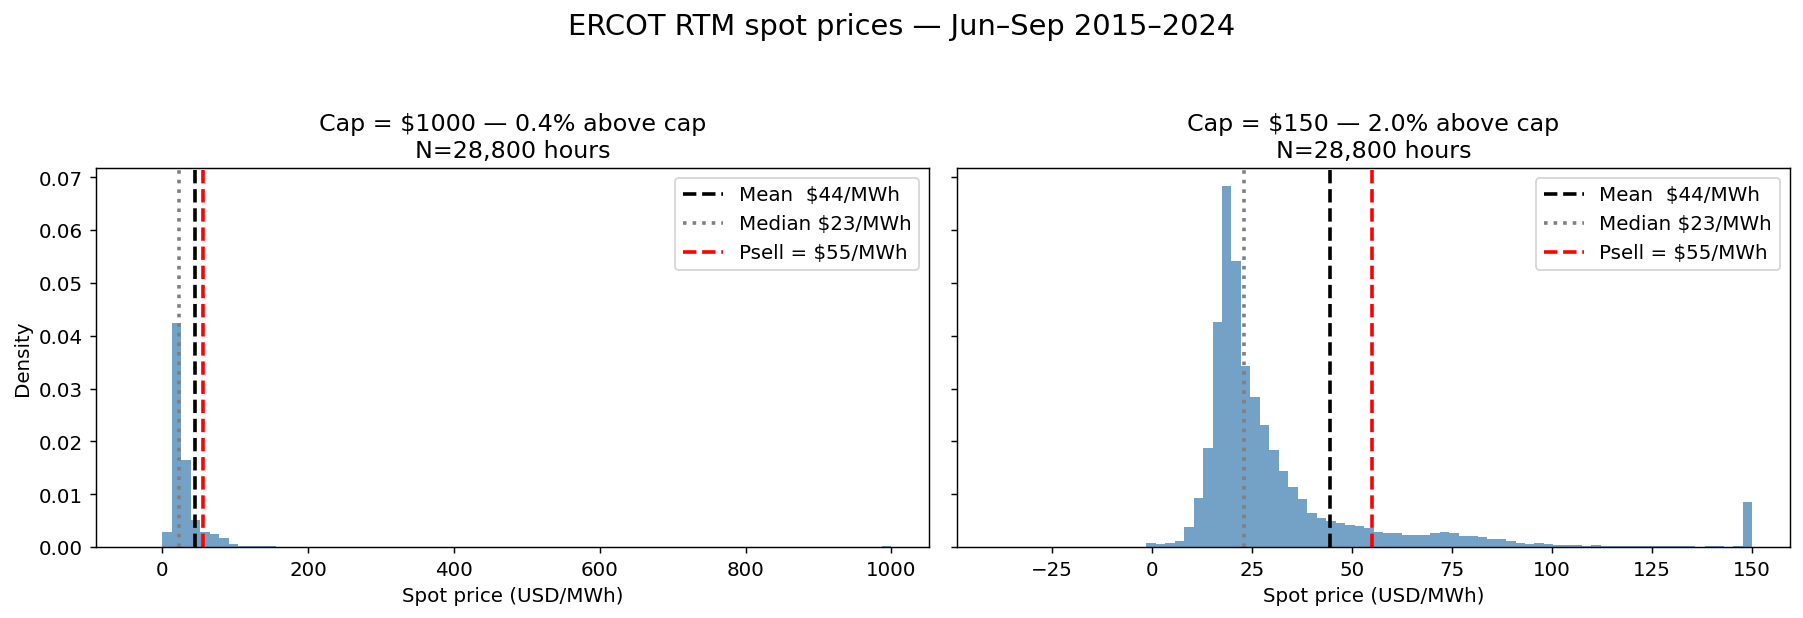

In [7]:
CAPS = [1000.0, 150.0]
all_prices = pi_mat.flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for i, CAP in enumerate(CAPS):
    pct_above = 100 * (all_prices > CAP).mean()
    shown = np.clip(all_prices, -np.inf, CAP)

    axes[i].hist(shown, bins=80, density=True, color='steelblue', alpha=0.75, edgecolor='none')
    axes[i].axvline(all_prices.mean(),   color='black', ls='--', lw=2, label=f'Mean  ${all_prices.mean():.0f}/MWh')
    axes[i].axvline(np.median(all_prices), color='gray',  ls=':',  lw=2, label=f'Median ${np.median(all_prices):.0f}/MWh')
    axes[i].axvline(PSELL, color='red', ls='--', lw=2, label=f'Psell = ${PSELL:.0f}/MWh')
    axes[i].set_xlabel('Spot price (USD/MWh)')
    axes[i].set_title(
        f'Cap = ${CAP:.0f} — {pct_above:.1f}% above cap\n'
        f'N={len(all_prices):,} hours'
    )
    if i == 0:
        axes[i].set_ylabel('Density')
    axes[i].legend()

fig.suptitle('ERCOT RTM spot prices — Jun–Sep 2015–2024', y=1.05, fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'price_histogram.png'))
plt.show()

## 2. DR dispatch — hourly frequency

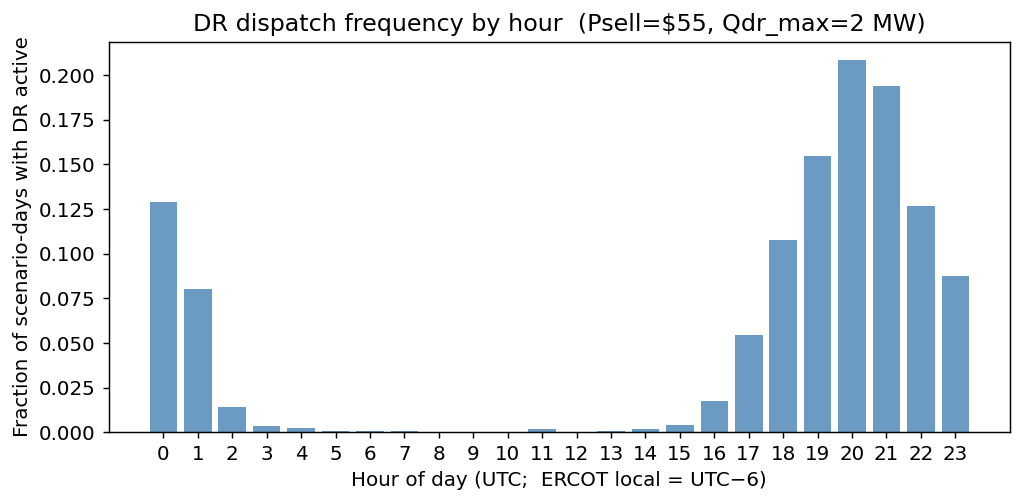

In [17]:
HOURS_PER_DAY = 24
hourly_rate = np.array([y_mat[h::HOURS_PER_DAY, :].mean() for h in range(HOURS_PER_DAY)])

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(24), hourly_rate, color='steelblue', alpha=0.8)
ax.set_xlabel('Hour of day (UTC;  ERCOT local = UTC−6)')
ax.set_ylabel('Fraction of scenario-days with DR active')
ax.set_title(f'DR dispatch frequency by hour  (Psell=${PSELL:.0f}, Qdr_max={QDR_MAX:.0f} MW)')
ax.set_xticks(range(24))
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'dr_hourly_freq.png'))
plt.show()

## 3. DR dispatch — price distribution

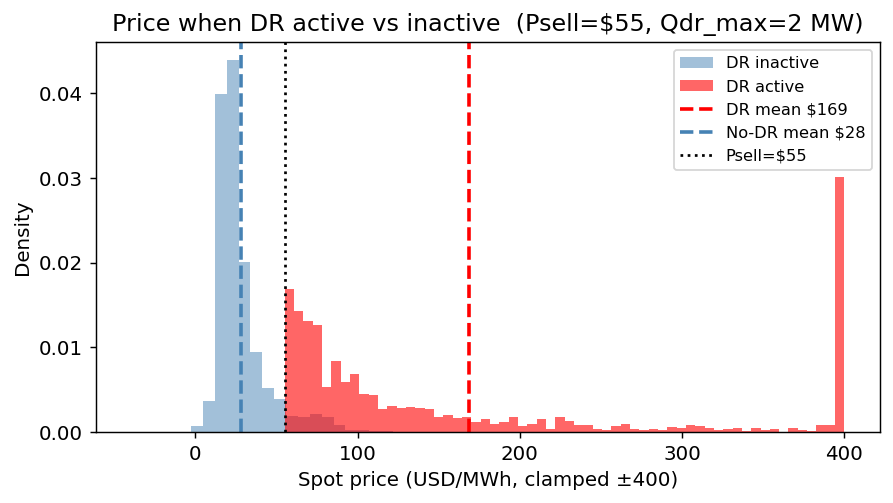

In [18]:
dr_mask    = y_mat == 1
prices_dr  = np.clip(pi_mat[dr_mask],  -100, 400)
prices_off = np.clip(pi_mat[~dr_mask], -100, 400)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(prices_off, bins=60, density=True, alpha=0.5, color='steelblue', label='DR inactive')
ax.hist(prices_dr,  bins=60, density=True, alpha=0.6, color='red',       label='DR active')
ax.axvline(prices_dr.mean(),  color='red',       ls='--', lw=2, label=f'DR mean ${prices_dr.mean():.0f}')
ax.axvline(prices_off.mean(), color='steelblue', ls='--', lw=2, label=f'No-DR mean ${prices_off.mean():.0f}')
ax.axvline(PSELL, color='black', ls=':', lw=1.5, label=f'Psell=${PSELL:.0f}')
ax.set_xlabel('Spot price (USD/MWh, clamped ±400)')
ax.set_ylabel('Density')
ax.set_title(f'Price when DR active vs inactive  (Psell=${PSELL:.0f}, Qdr_max={QDR_MAX:.0f} MW)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'dr_price_distribution.png'))
plt.show()

## 4. Ranked scenario profits

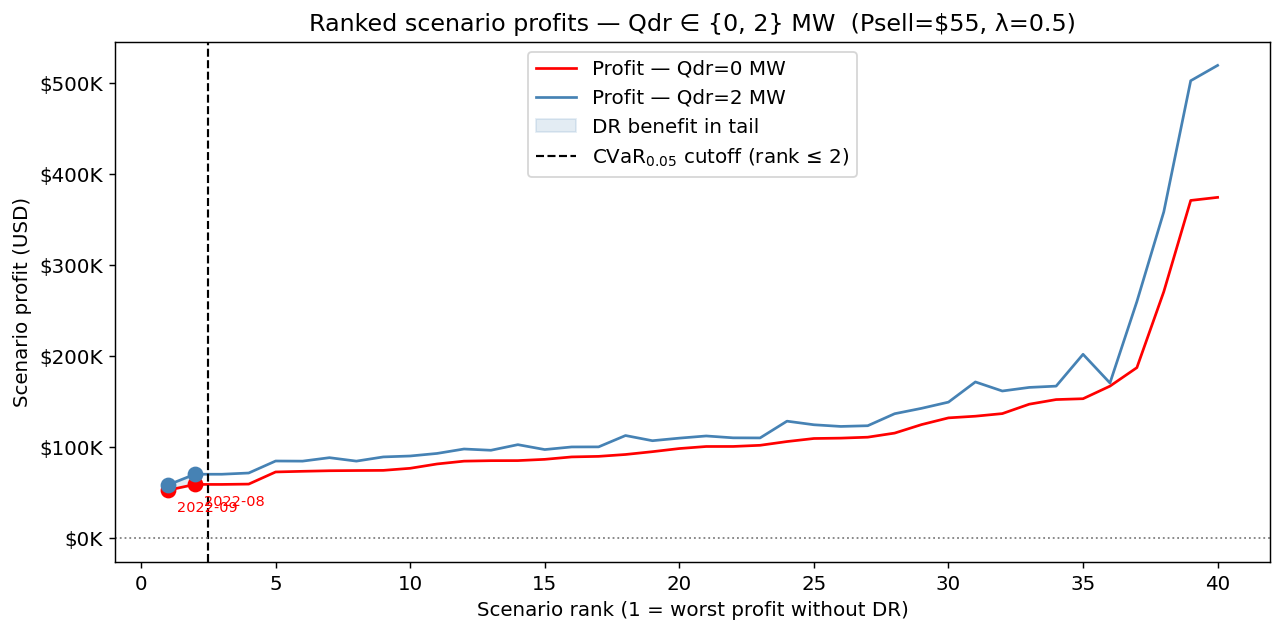

In [19]:
p0 = tail_df['profit_qdr0'].values
p_max = tail_df[f'profit_{qdr_max_label}'].values
order = np.argsort(p0)
p0_sorted    = p0[order]
pmax_sorted  = p_max[order]
labels_sorted = tail_df['scenario'].values[order]
ranks = np.arange(1, N+1)
n_tail = max(1, int(np.floor(ALPHA * N)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ranks, p0_sorted,   color='red',      lw=1.5, label='Profit — Qdr=0 MW')
ax.plot(ranks, pmax_sorted, color='steelblue', lw=1.5, label=f'Profit — Qdr={QDR_MAX:.0f} MW')
ax.fill_between(ranks[:n_tail], p0_sorted[:n_tail], pmax_sorted[:n_tail],
                alpha=0.15, color='steelblue', label='DR benefit in tail')
ax.scatter(ranks[:n_tail], p0_sorted[:n_tail],   color='red',      s=60, zorder=5)
ax.scatter(ranks[:n_tail], pmax_sorted[:n_tail], color='steelblue', s=60, zorder=5)
ax.axvline(n_tail + 0.5, color='black', ls='--', lw=1.2,
           label=f'CVaR$_{{0.05}}$ cutoff (rank ≤ {n_tail})')
for r in range(n_tail):
    ax.annotate(labels_sorted[r], (r+1, p0_sorted[r]),
                xytext=(5, -12), textcoords='offset points', fontsize=8, color='red')
ax.axhline(0, color='gray', ls=':', lw=1)
ax.set_xlabel('Scenario rank (1 = worst profit without DR)')
ax.set_ylabel('Scenario profit (USD)')
ax.set_title(f'Ranked scenario profits — Qdr ∈ {{0, {QDR_MAX:.0f}}} MW  '
             f'(Psell=${PSELL:.0f}, λ={LAMBDA})')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'ranked_scenario_profits.png'))
plt.show()

## 5. Tail price scenario paths

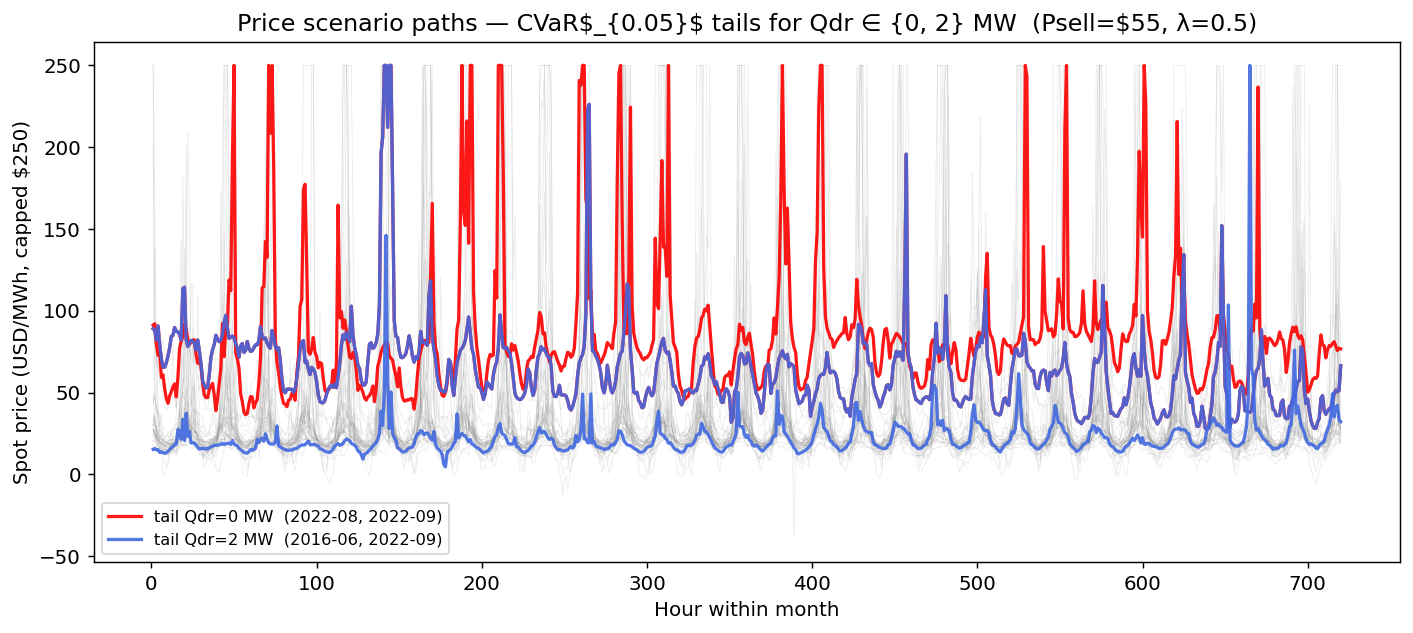

In [20]:
tail0_idx  = np.where(tail_df['in_tail_qdr0'].values)[0]
tailmax_idx = np.where(tail_df[f'in_tail_{qdr_max_label}'].values)[0]
tail0_labels  = tail_df['scenario'].values[tail0_idx]
tailmax_labels = tail_df['scenario'].values[tailmax_idx]

CAP2 = 250.0
px   = np.clip(pi_mat, -np.inf, CAP2)
hrs  = np.arange(1, T+1)

fig, ax = plt.subplots(figsize=(11, 5))
for j in range(N):
    ax.plot(hrs, px[:, j], color='gray', alpha=0.15, lw=0.5)

for k, j in enumerate(tail0_idx):
    joined0 = ', '.join(tail0_labels)
    lbl = f'tail Qdr=0 MW  ({joined0})' if k == 0 else ''
    ax.plot(hrs, px[:, j], color='red', alpha=0.9, lw=1.8, label=lbl)

for k, j in enumerate(tailmax_idx):
    joined_max = ', '.join(tailmax_labels)
    lbl = f'tail Qdr={QDR_MAX:.0f} MW  ({joined_max})' if k == 0 else ''
    ax.plot(hrs, px[:, j], color='royalblue', alpha=0.9, lw=1.8, label=lbl)

ax.set_xlabel('Hour within month')
ax.set_ylabel(f'Spot price (USD/MWh, capped ${CAP2:.0f})')
ax.set_title(f'Price scenario paths — CVaR$_{{0.05}}$ tails for Qdr ∈ {{0, {QDR_MAX:.0f}}} MW  '
             f'(Psell=${PSELL:.0f}, λ={LAMBDA})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'tail_price_scenarios.png'))
plt.show()


## 6. Profit vs DR capacity (if sweep exists)

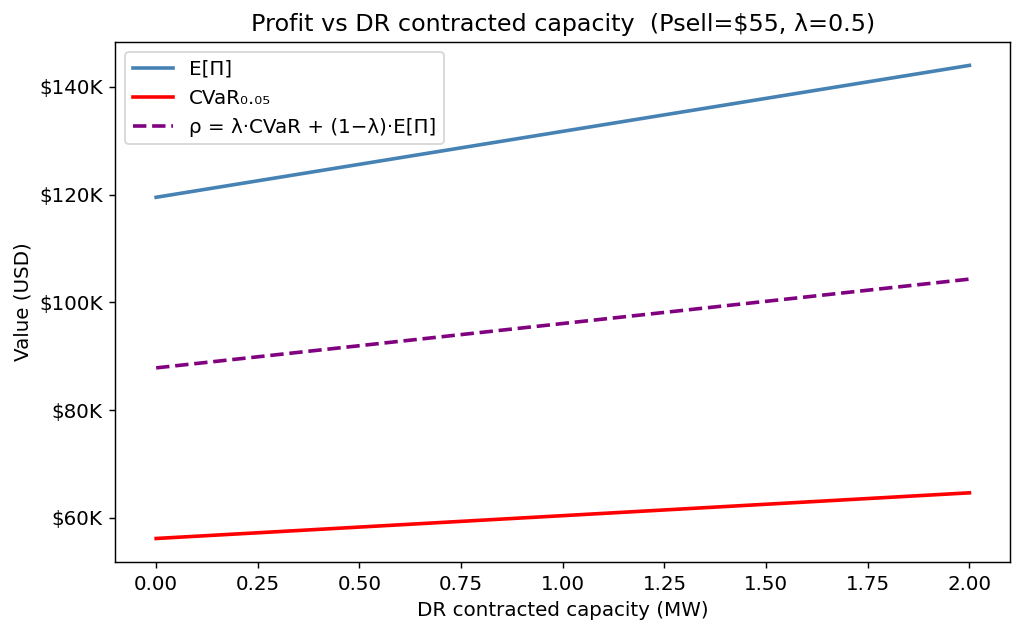

In [21]:
sweep_path = os.path.join(RESULTS_DIR, 'sweep_qdr_capacity.csv')
if os.path.exists(sweep_path):
    qdr = pd.read_csv(sweep_path)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(qdr['Qdr_max'], qdr['EΠ'],  color='steelblue', lw=2, label='E[Π]')
    ax.plot(qdr['Qdr_max'], qdr['CVaR'], color='red',       lw=2, label='CVaR₀.₀₅')
    ax.plot(qdr['Qdr_max'], qdr['ρ'],    color='purple',    lw=2, ls='--',
            label=f'ρ = λ·CVaR + (1−λ)·E[Π]')
    ax.set_xlabel('DR contracted capacity (MW)')
    ax.set_ylabel('Value (USD)')
    ax.set_title(f'Profit vs DR contracted capacity  (Psell=${PSELL:.0f}, λ={LAMBDA})')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'profit_vs_qdr.png'))
    plt.show()
else:
    print('sweep_qdr_capacity.csv not found — run the Qdr sweep in task4.jl first.')

## 7. Willingness-to-supply — Psell sweep

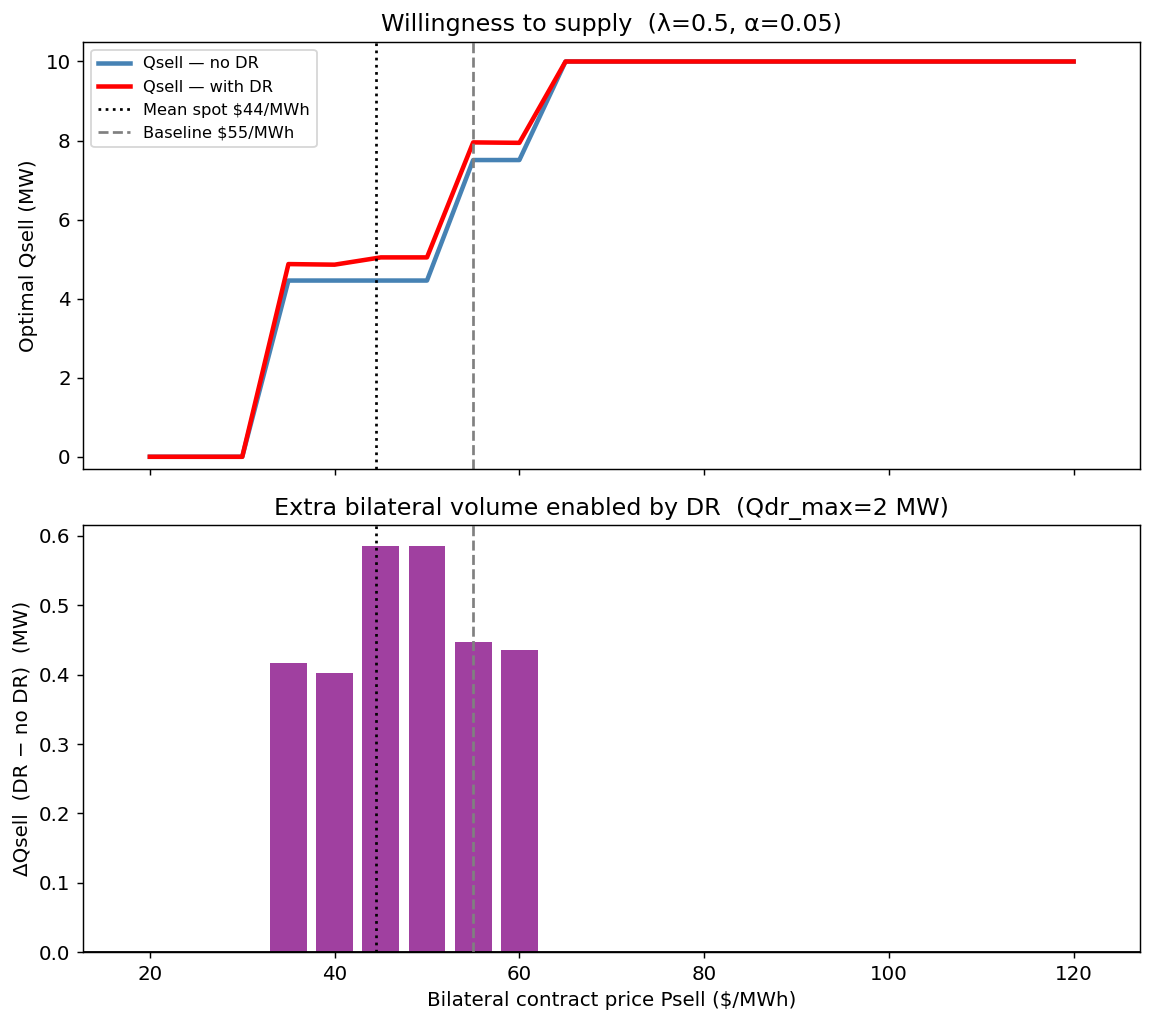

In [30]:
psell_df = pd.read_csv(os.path.join(RESULTS_DIR, 'sweep_bilateral_price.csv'))
ws  = psell_df[psell_df['config'] == 'Wind+Solar'].sort_values('Psell').reset_index(drop=True)
wsd = psell_df[psell_df['config'] == 'Wind+Solar+DR'].sort_values('Psell').reset_index(drop=True)
mean_price = pi_mat.mean()
delta_qsell = wsd['Qsell'] - ws['Qsell']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

# ── Top: Qsell comparison ─────────────────────────────────────────────────────
# ax1.axvspan(ws['Psell'].min(), mean_price, alpha=0.06, color='red',    label='Psell < mean spot: sell nothing')
# ax1.axvspan(mean_price, 65,               alpha=0.06, color='orange',  label='Interior solution')
# ax1.axvspan(65, ws['Psell'].max(),        alpha=0.06, color='green',   label='Psell >> mean: sell max')
ax1.plot(ws['Psell'],  ws['Qsell'],  color='steelblue', lw=2.5, label='Qsell — no DR')
ax1.plot(wsd['Psell'], wsd['Qsell'], color='red',       lw=2.5, label='Qsell — with DR')
ax1.axvline(mean_price, color='black', ls=':', lw=1.5, label=f'Mean spot ${mean_price:.0f}/MWh')
ax1.axvline(PSELL,      color='gray',  ls='--', lw=1.5, label=f'Baseline ${PSELL:.0f}/MWh')
ax1.set_ylabel('Optimal Qsell (MW)')
ax1.set_ylim(-0.3, 10.5)
ax1.set_title(f'Willingness to supply  (λ={LAMBDA}, α={ALPHA})')
ax1.legend(fontsize=9)

# ── Bottom: DR uplift ─────────────────────────────────────────────────────────
ax2.bar(ws['Psell'], delta_qsell, width=4, color='purple', alpha=0.75)
ax2.axhline(0, color='black', lw=1)
ax2.axvline(mean_price, color='black', ls=':', lw=1.5)
ax2.axvline(PSELL,      color='gray',  ls='--', lw=1.5)
ax2.set_xlabel('Bilateral contract price Psell ($/MWh)')
ax2.set_ylabel('ΔQsell  (DR − no DR)  (MW)')
ax2.set_title(f'Extra bilateral volume enabled by DR  (Qdr_max={QDR_MAX:.0f} MW)')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'willingness_to_supply.png'))
plt.show()


## 8. Certainty equivalent & DR benefit

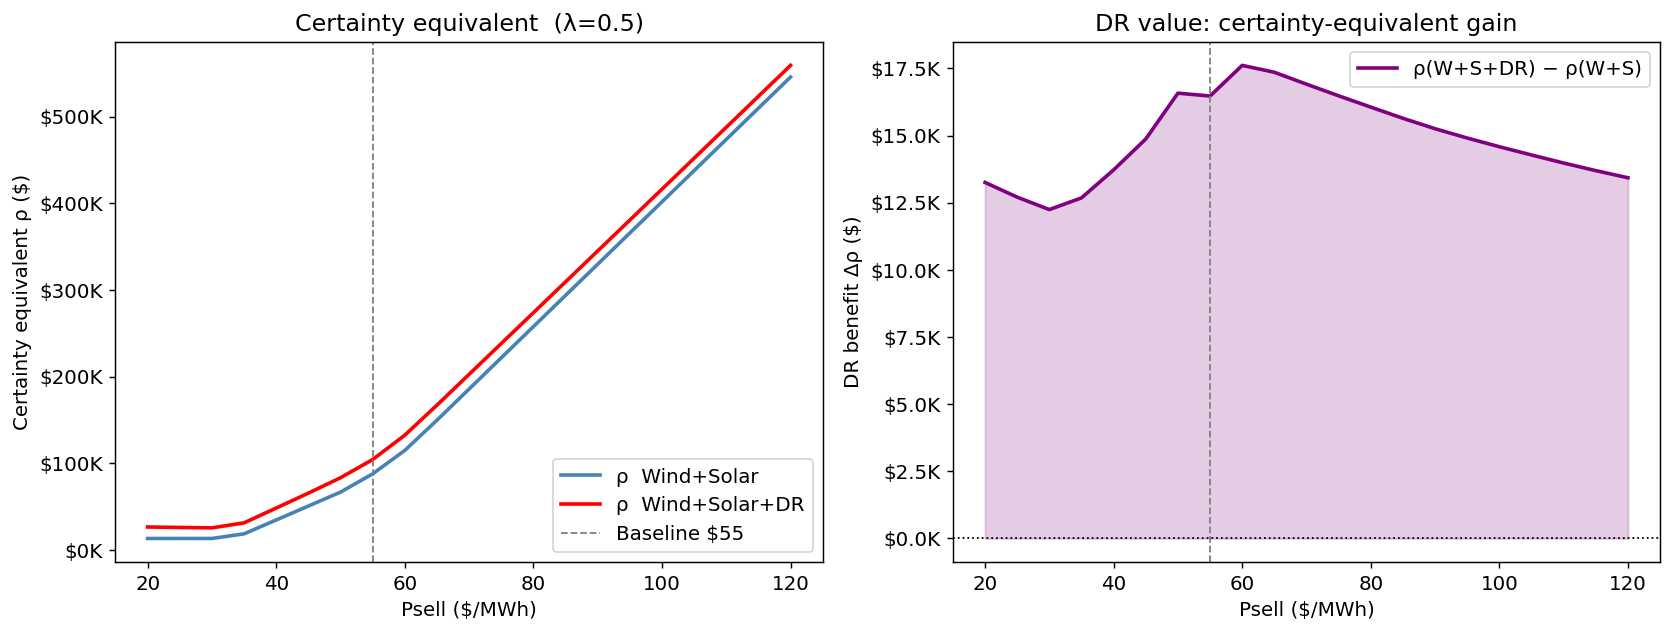

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(ws['Psell'],  ws['ρ'],  color='steelblue', lw=2, label='ρ  Wind+Solar')
ax1.plot(wsd['Psell'], wsd['ρ'], color='red',       lw=2, label='ρ  Wind+Solar+DR')
ax1.axvline(PSELL, color='gray', ls='--', lw=1, label=f'Baseline ${PSELL:.0f}')
ax1.set_xlabel('Psell ($/MWh)')
ax1.set_ylabel('Certainty equivalent ρ ($)')
ax1.set_title(f'Certainty equivalent  (λ={LAMBDA})')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax1.legend()

dr_benefit = wsd['ρ'].values - ws['ρ'].values
ax2.plot(wsd['Psell'], dr_benefit, color='purple', lw=2, label='ρ(W+S+DR) − ρ(W+S)')
ax2.fill_between(wsd['Psell'], 0, dr_benefit, where=(dr_benefit > 0),
                 alpha=0.2, color='purple')
ax2.axhline(0, color='black', ls=':', lw=1)
ax2.axvline(PSELL, color='gray', ls='--', lw=1)
ax2.set_xlabel('Psell ($/MWh)')
ax2.set_ylabel('DR benefit Δρ ($)')
ax2.set_title('DR value: certainty-equivalent gain')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.1f}K'))
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'certainty_equivalent.png'))
plt.show()


## 9. Risk-return frontier — λ sweep

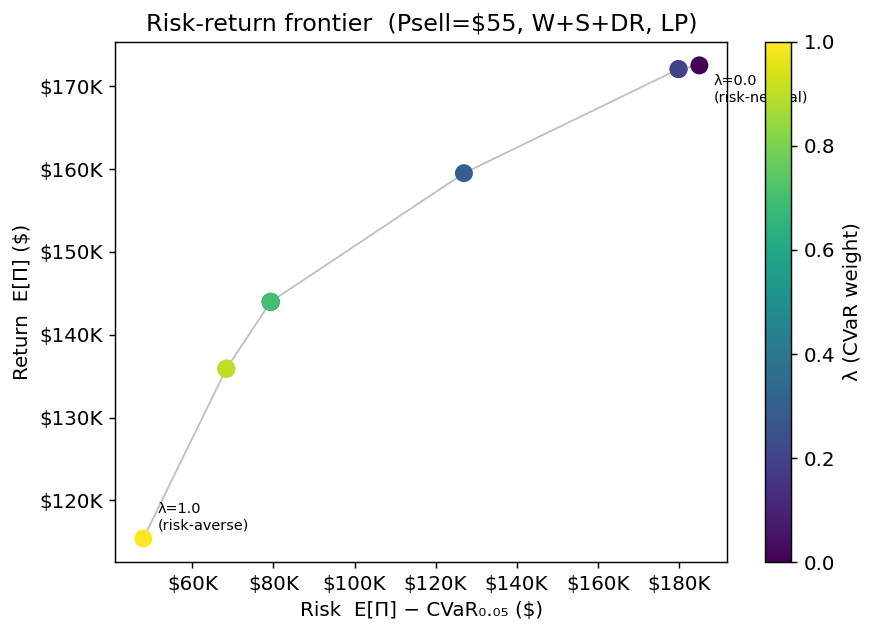

In [27]:
lambda_df = pd.read_csv(os.path.join(RESULTS_DIR, 'sweep_risk_weight.csv'))
lambda_df = lambda_df.sort_values('λ')

risk   = lambda_df['EΠ'] - lambda_df['CVaR']   # risk premium
ret    = lambda_df['EΠ']
lam    = lambda_df['λ']

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(risk, ret, c=lam, cmap='viridis', s=80, zorder=5)
ax.plot(risk, ret, color='gray', lw=1, alpha=0.5)
plt.colorbar(sc, ax=ax, label='λ (CVaR weight)')
# Annotate endpoints
ax.annotate(f'λ={lam.iloc[0]:.1f}\n(risk-neutral)',
            (risk.iloc[0], ret.iloc[0]),  xytext=(8, -20), textcoords='offset points', fontsize=8)
ax.annotate(f'λ={lam.iloc[-1]:.1f}\n(risk-averse)',
            (risk.iloc[-1], ret.iloc[-1]), xytext=(8, 5),  textcoords='offset points', fontsize=8)
ax.set_xlabel('Risk  E[Π] − CVaR₀.₀₅ ($)')
ax.set_ylabel('Return  E[Π] ($)')
ax.set_title(f'Risk-return frontier  (Psell=${PSELL:.0f}, W+S+DR, LP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'risk_return_frontier.png'))
plt.show()
